# Getting Started with SynForecast

This tutorial covers the basics of generating synthetic time series data with SynForecast. You will learn how to create generators, configure parameters, inject patterns, and combine multiple generators into datasets.

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast import SynSet
from synforecast.generators import RandomWalkGenerator, SeasonalGenerator

## Create a Simple Generator

Every generator takes a dictionary of parameters. At minimum, you specify the series length and frequency.

In [ ]:
generator = RandomWalkGenerator(engine="polars", **{
    "min_length": 100,
    "max_length": 100,
    "freq": "D",
    "seed": 42,
})

df = generator.generate(n_series=3)
df.head(10)

unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-1.401594
"""0""",2000-01-02 00:00:00,-2.307539
"""0""",2000-01-03 00:00:00,-1.352484
"""0""",2000-01-04 00:00:00,-1.011828
"""0""",2000-01-05 00:00:00,-1.511372
"""0""",2000-01-06 00:00:00,-2.176202
"""0""",2000-01-07 00:00:00,-1.574639
"""0""",2000-01-08 00:00:00,-1.915517
"""0""",2000-01-09 00:00:00,-1.746987


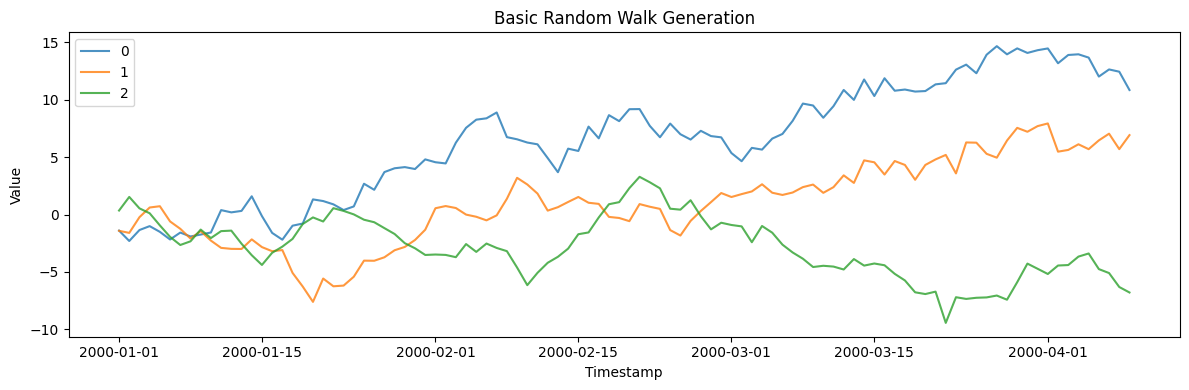

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df["unique_id"].unique().to_list():
    series = df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Basic Random Walk Generation")
ax.legend()
plt.tight_layout()
plt.show()

## Configure Generator Parameters

Each generator has specific parameters that control the shape of the output. For `RandomWalkGenerator`, you can set drift, volatility, and start value.

In [ ]:
generator = RandomWalkGenerator(engine="polars", **{
    "min_length": 100,
    "max_length": 150,
    "freq": "h",
    "drift": 0.1,
    "volatility": 1.5,
    "start_value": 100.0,
    "seed": 42,
})

df = generator.generate(n_series=2)
print(f"Generated {df['unique_id'].n_unique()} series, {len(df)} total rows")
df.head(10)

Generated 2 series, 243 total rows


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,97.970343
"""0""",2000-01-01 01:00:00,97.797686
"""0""",2000-01-01 02:00:00,99.952696
"""0""",2000-01-01 03:00:00,101.316565
"""0""",2000-01-01 04:00:00,101.585458
"""0""",2000-01-01 05:00:00,99.693524
"""0""",2000-01-01 06:00:00,98.830769
"""0""",2000-01-01 07:00:00,97.657048
"""0""",2000-01-01 08:00:00,98.728945


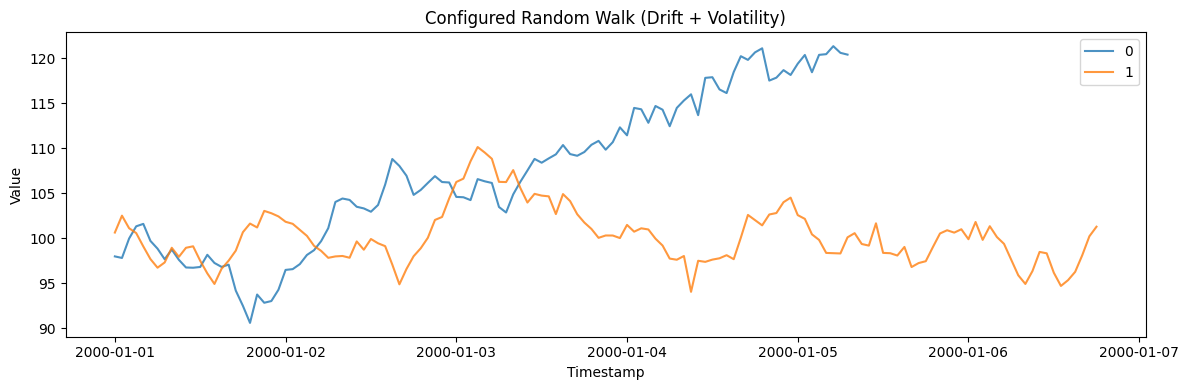

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df["unique_id"].unique().to_list():
    series = df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Configured Random Walk (Drift + Volatility)")
ax.legend()
plt.tight_layout()
plt.show()

## Pattern Injection

SynForecast can inject realistic patterns into generated data: anomalies, changepoints, and missing values. These are configured through the generator parameters.

In [ ]:
generator = RandomWalkGenerator(engine="polars", **{
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "start_value": 100.0,
    "seed": 42,
    # Enable anomalies
    "anomalies": True,
    "anomaly_fraction": 0.05,
    "anomaly_types": ["spike", "dip"],
    # Enable changepoints
    "changepoints": True,
    "num_changepoints": 2,
    "changepoint_type": "level",
    # Enable missing data
    "missing_data": True,
    "missing_rate": 0.03,
})

df = generator.generate(n_series=1)
print(f"Null values: {df['y'].null_count()}")
df.head(10)

Null values: 0


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,98.598406
"""0""",2000-01-02 00:00:00,97.692461
"""0""",2000-01-03 00:00:00,98.647516
"""0""",2000-01-04 00:00:00,98.988172
"""0""",2000-01-05 00:00:00,98.488628
"""0""",2000-01-06 00:00:00,97.823798
"""0""",2000-01-07 00:00:00,98.425361
"""0""",2000-01-08 00:00:00,108.084483
"""0""",2000-01-09 00:00:00,NaN


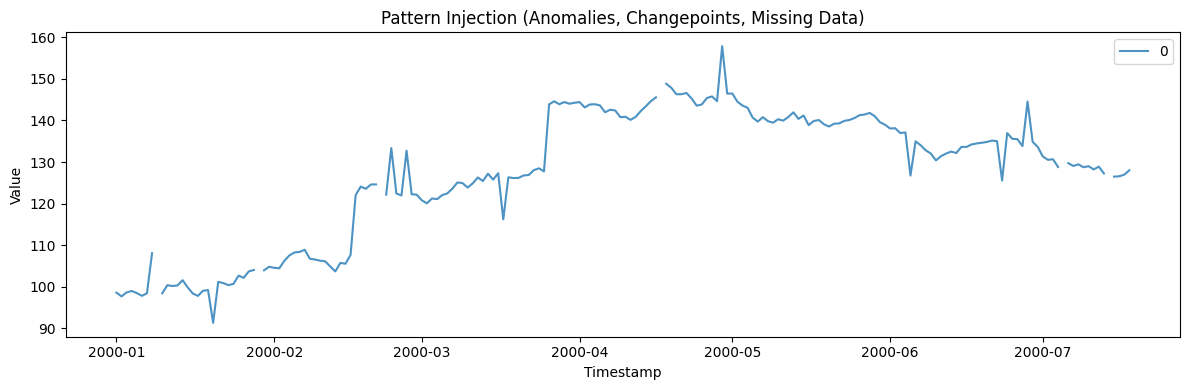

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df["unique_id"].unique().to_list():
    series = df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Pattern Injection (Anomalies, Changepoints, Missing Data)")
ax.legend()
plt.tight_layout()
plt.show()

## Combining Generators with SynSet

`SynSet` lets you combine multiple generators into a single unified dataset. Each generator contributes a batch of series.

In [ ]:
generators = [
    RandomWalkGenerator(engine="polars", **{
        "min_length": 100,
        "max_length": 100,
        "freq": "D",
        "seed": 1,
    }),
    SeasonalGenerator(engine="polars", **{
        "min_length": 100,
        "max_length": 100,
        "freq": "D",
        "seasonality_period": 7,
        "seed": 2,
    }),
]

synset = SynSet(generators)
df = synset.generate(n_series_per_generator=2)
print(f"Total unique series: {df['unique_id'].n_unique()}")
df.head(10)

Total unique series: 4


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-0.75549
"""0""",2000-01-02 00:00:00,-0.60759
"""0""",2000-01-03 00:00:00,1.274036
"""0""",2000-01-04 00:00:00,0.87971
"""0""",2000-01-05 00:00:00,-0.002609
"""0""",2000-01-06 00:00:00,-0.914103
"""0""",2000-01-07 00:00:00,-0.132172
"""0""",2000-01-08 00:00:00,0.986832
"""0""",2000-01-09 00:00:00,1.833801


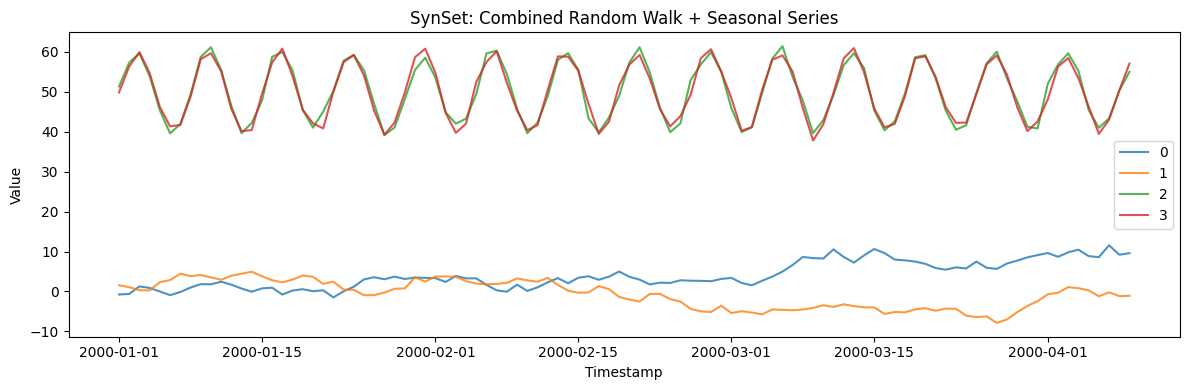

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df["unique_id"].unique().to_list():
    series = df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("SynSet: Combined Random Walk + Seasonal Series")
ax.legend()
plt.tight_layout()
plt.show()

## Next Steps

SynForecast includes 17+ generators covering statistical models (SARIMA, ETS), stochastic processes (GARCH, Ornstein-Uhlenbeck, GBM), and domain-specific patterns (IoT, energy, demand). Explore the other example notebooks to learn more about each generator.